# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

Domínio: Negócios / Objetivo: observar comportamentos dos clientes de uma empresa de telecomunicações / tipo: uso dos serviços, reclamações, chamadas, mensagens SMS, tempo de assinatura, idade dos clientes, valores cobrados e outras informações.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
TARGET_COLUMN = "Churn"

In [5]:
TARGET_COLUMN = "Churn"
display(df.head())

print(df.shape)

amostra = df.shape[0]
coluna = df.shape[1]
atributo = coluna - 1

print(amostra)
print(atributo)
print(coluna)
print(TARGET_COLUMN)
print(df[TARGET_COLUMN].unique())
print(df[TARGET_COLUMN].nunique())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


(3150, 14)
3150
13
14
Churn
[0 1]
2


O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

,Contagem,Proporção (%)
Churn,,
0,2655,84.29
1,495,15.71


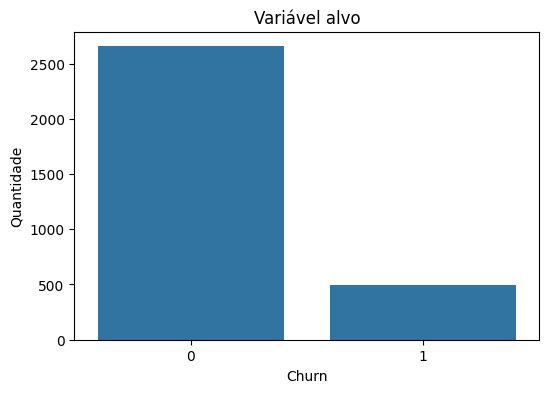

In [6]:
contagem_classes = df[TARGET_COLUMN].value_counts().sort_index()
proporcao_classes = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Contagem": contagem_classes,
    "Proporção (%)": proporcao_classes.round(2)
}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Variável alvo")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Quantidade")
plt.show()

A distribuição mostra que o dataset é desbalanceado, debvido ao excesso de amostras na classe 0

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

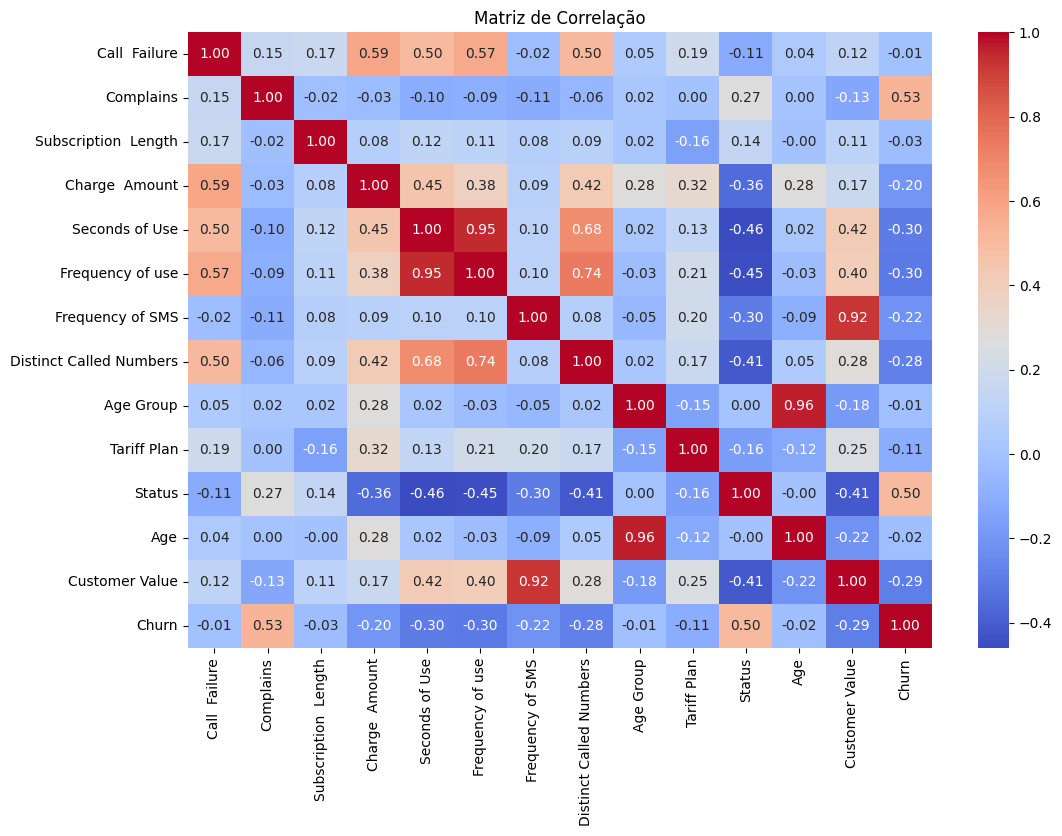

Correlação dos atributos com a variável alvo:


,Correlação com Churn
Complains,0.532053
Status,0.498976
Frequency of use,-0.303337
Seconds of Use,-0.298935
Customer Value,-0.289144
Distinct Called Numbers,-0.278867
Frequency of SMS,-0.220754
Charge Amount,-0.202305
Tariff Plan,-0.105853
Subscription Length,-0.032588


Maiores correlações positivas:


,Correlação positiva
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705


Maiores correlações negativas:


,Correlação negativa
Frequency of use,-0.303337
Seconds of Use,-0.298935
Customer Value,-0.289144
Distinct Called Numbers,-0.278867
Frequency of SMS,-0.220754


In [7]:
correlacao = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

correlacao_churn = correlacao[TARGET_COLUMN].drop(TARGET_COLUMN)

print("Correlação dos atributos com a variável alvo:")
display(correlacao_churn.sort_values(key=abs, ascending=False).to_frame("Correlação com Churn"))

print("Maiores correlações positivas:")
display(correlacao_churn.sort_values(ascending=False).head(5).to_frame("Correlação positiva"))

print("Maiores correlações negativas:")
display(correlacao_churn.sort_values(ascending=True).head(5).to_frame("Correlação negativa"))

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

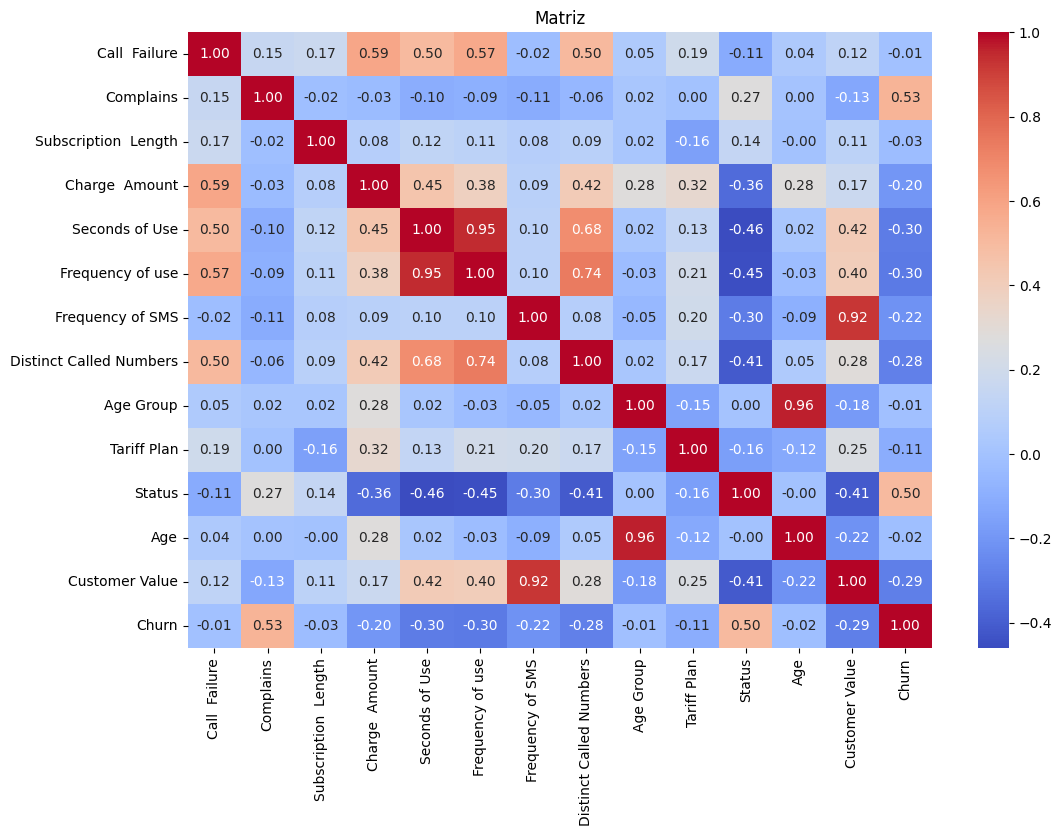

,Correlação com Churn
Complains,0.532053
Status,0.498976
Frequency of use,-0.303337
Seconds of Use,-0.298935
Customer Value,-0.289144
Distinct Called Numbers,-0.278867
Frequency of SMS,-0.220754
Charge Amount,-0.202305
Tariff Plan,-0.105853
Subscription Length,-0.032588


,Correlação positiva
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705


,Correlação negativa
Frequency of use,-0.303337
Seconds of Use,-0.298935
Customer Value,-0.289144
Distinct Called Numbers,-0.278867
Frequency of SMS,-0.220754


In [9]:
correlacao = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz")
plt.show()
co = correlacao[TARGET_COLUMN].drop(TARGET_COLUMN)

display(co.sort_values(key=abs, ascending=False).to_frame("Correlação com Churn"))
display(co.sort_values(ascending=False).head(5).to_frame("Correlação positiva"))
display(co.sort_values(ascending=True).head(5).to_frame("Correlação negativa"))

Os atributos mais correlacionados são Complains e Status , indicando relação positiva com o cancelamento. Já os atributoss Seconds of Use, Frequency of use, Customer Value e Distinct Called Numbers têm correlação negativa, mas também podem ser relevantes para a classificação.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
scaledx = scaler.fit_transform(X_train)
testx = scaler.transform(X_test)

print(scaledx.shape)
print(testx.shape)
print(y_train.shape)
print(y_test.shape)

(2520, 13)
(630, 13)
(2520,)
(630,)


A padronização é importante nesse contexto para colocar todos os atributos na mesma escala, sendo o FIT usado para que o StandardScaler reconheça a média e o desvio padrão

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [11]:
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(scaledx, y_train)

print(modelo.n_iter_[0])
print(modelo.max_iter)

if modelo.n_iter_[0] < modelo.max_iter:
    print("Conversão realizada.")
else:
    print("erro na conversão.")

42
1000
Conversão realizada.


A regressão logística tem o papel de classificar se um cliente pertence à classe 0 ou 1 da variável Churn, ou seja, se ele tende ou não a cancelar o serviço. O modelo está aprendendo, a partir dos atributos dos clientes, quais características aumentam ou diminuem a probabilidade de churn.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [14]:
p = modelo.predict_proba(testx)

print(modelo.classes_)
print(p[:10])

[0 1]
[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]
 [9.97154922e-01 2.84507844e-03]
 [9.91458577e-01 8.54142300e-03]
 [9.91454963e-01 8.54503750e-03]
 [9.87024986e-01 1.29750142e-02]
 [5.90190333e-01 4.09809667e-01]]


Vendo os valores, a maioria das previsões apresenta alta confiança para a classe 0, Porém, em alguns casos, como 0.5901, 0.4098, o modelo apresenta menor confiança.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [16]:
from sklearn.metrics import confusion_matrix

proba_churn = p[:, 1]
pred05 = (proba_churn >= 0.5).astype(int)
pred07 = (proba_churn >= 0.7).astype(int)
tn05, fp05, fn05, tp05 = confusion_matrix(y_test, pred05).ravel()
tn07, fp07, fn07, tp07 = confusion_matrix(y_test, pred07).ravel()

resultado = pd.DataFrame({
    "Limiar": [0.5, 0.7],
    "Previstos como 0": [(pred05 == 0).sum(), (pred07 == 0).sum()],
    "Previstos como 1": [(pred05 == 1).sum(), (pred07 == 1).sum()],
    "Falsos Positivos": [fp05, fp07],
    "Falsos Negativos": [fn05, fn07]
})
display(resultado)

,Limiar,Previstos como 0,Previstos como 1,Falsos Positivos,Falsos Negativos
0,0.5,570,60,16,66
1,0.7,588,42,6,74


o modelo passa a exigir uma. probabilidade maior para classificar um cliente como Churn igual a 1

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

proba_churn = p[:, 1]

def avaliar_limiar(limiar):
    pred = (proba_churn >= limiar).astype(int)
    return {
        "Limiar": limiar,
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "Matriz de Confusão": confusion_matrix(y_test, pred)
    }
resultado_05 = avaliar_limiar(0.5)
resultado_07 = avaliar_limiar(0.7)

metricas = pd.DataFrame([
    {
        "Limiar": resultado_05["Limiar"],
        "Acurácia": resultado_05["Acurácia"],
        "Precisão": resultado_05["Precisão"],
        "Recall": resultado_05["Recall"],
        "F1-score": resultado_05["F1-score"]
    },
    {
        "Limiar": resultado_07["Limiar"],
        "Acurácia": resultado_07["Acurácia"],
        "Precisão": resultado_07["Precisão"],
        "Recall": resultado_07["Recall"],
        "F1-score": resultado_07["F1-score"]
    }
])
display(metricas)
display(pd.DataFrame(resultado_05["Matriz de Confusão"],
                     index=["Real 0", "Real 1"],
                     columns=["Previsto 0", "Previsto 1"]))
display(pd.DataFrame(resultado_07["Matriz de Confusão"],
                     index=["Real 0", "Real 1"],
                     columns=["Previsto 0", "Previsto 1"]))

,Limiar,Acurácia,Precisão,Recall,F1-score
0,0.5,0.869841,0.733333,0.400000,0.517647
1,0.7,0.873016,0.857143,0.327273,0.473684


,Previsto 0,Previsto 1
Real 0,504,16
Real 1,66,44


,Previsto 0,Previsto 1
Real 0,514,6
Real 1,74,36


Ao aumentar o limiar de 0.5 para 0.7, o modelo fica mais rígido para prever Churn = 1. Isso tende a reduzir falsos positivos e aumentar a precisão, mas pode aumentar falsos negativos e reduzir o recall.


# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [19]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [27]:
TARGET_COLUMN = ds.variables[ds.variables["role"] == "Target"]["name"].iloc[0]

display(df.head())

print(df.shape)
print(TARGET_COLUMN)
print(df[TARGET_COLUMN].unique())
print(df[TARGET_COLUMN].nunique())

amostras = df.shape[0]
atributos = df.shape[1] - 1

print(amostras)
print(atributos)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


(58101, 55)
Cover_Type
[1 2 3 5 6 7 4]
7
58101
54


Possui 58101 amostras e 55 colunas no total. A variável alvo é Cover_Type. Observando os valores únicos dessa variável, percebe-se que ela possui mais de dois valores possíveis, portanto o problema não é de classificação binária, mas sim de classificação multiclasse.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

,Contagem,Proporção (%)
Cover_Type,,
1,21297,36.66
2,28248,48.62
3,3607,6.21
4,259,0.45
5,932,1.60
6,1706,2.94
7,2052,3.53


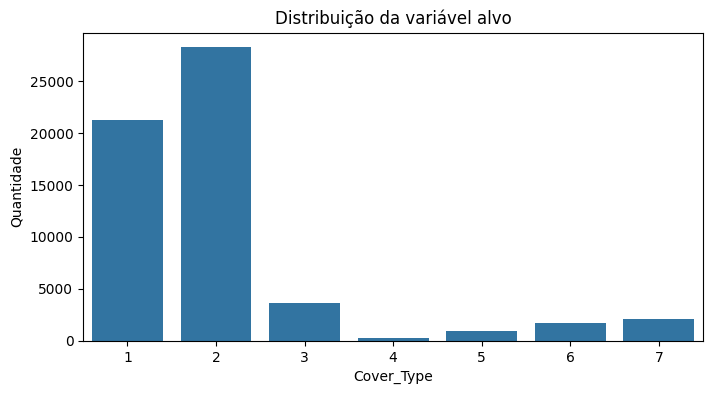

In [28]:
contagem = df[TARGET_COLUMN].value_counts().sort_index()
proporcao = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Contagem": contagem,
    "Proporção (%)": proporcao.round(2)
}))

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=TARGET_COLUMN, order=contagem.index)
plt.title("Distribuição da variável alvo")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Quantidade")
plt.show()

Pela distribuição da variável, o dataset é desbalanceado, pois algumas classes possuem muito mais amostras do que outras. As classes com maior quantidade aparecem com uma proporção bem superior, enquanto outras classes possuem poucas amostras. Isso indica que o modelo pode ter mais facilidade para aprender as classes majoritárias e mais dificuldade para identificar corretamente as classes minoritárias.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

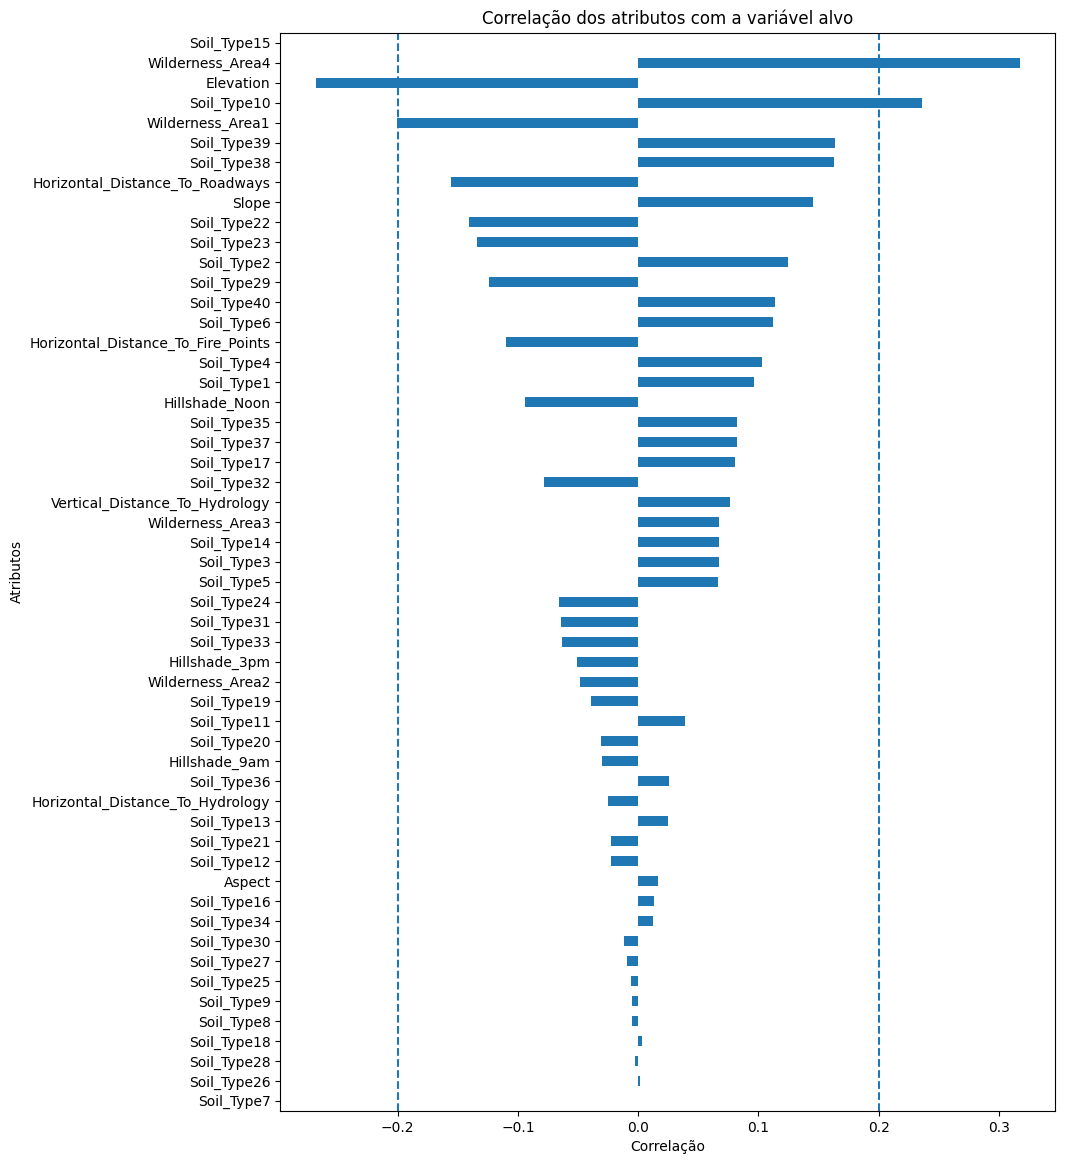

,Correlação
Wilderness_Area4,0.317518
Elevation,-0.268264
Soil_Type10,0.236392
Wilderness_Area1,-0.200715
Soil_Type39,0.163504
Soil_Type38,0.162663
Horizontal_Distance_To_Roadways,-0.155258
Slope,0.145731
Soil_Type22,-0.140253
Soil_Type23,-0.133668


In [29]:
correl = df.corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)

correl_ordenada = correl.reindex(
    correl.abs().sort_values(ascending=True).index
)
plt.figure(figsize=(10, 14))
correl_ordenada.plot(kind="barh")

plt.axvline(0.2, linestyle="--")
plt.axvline(-0.2, linestyle="--")
plt.title("Correlação dos atributos com a variável alvo")
plt.xlabel("Correlação")
plt.ylabel("Atributos")
plt.show()

display(
    correl.reindex(
        correl.abs().sort_values(ascending=False).index
    ).to_frame("Correlação")
)

As variáveis mais relevantes para o modelo são aquelas com maior correlação em valor absoluto com a variável alvo, principalmente as que ultrapassam o limiar heurístico de |r| = 0.2. Esses atributos podem ter maior influência na classificação, pois apresentam uma relação linear mais forte com o tipo de cobertura previsto.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

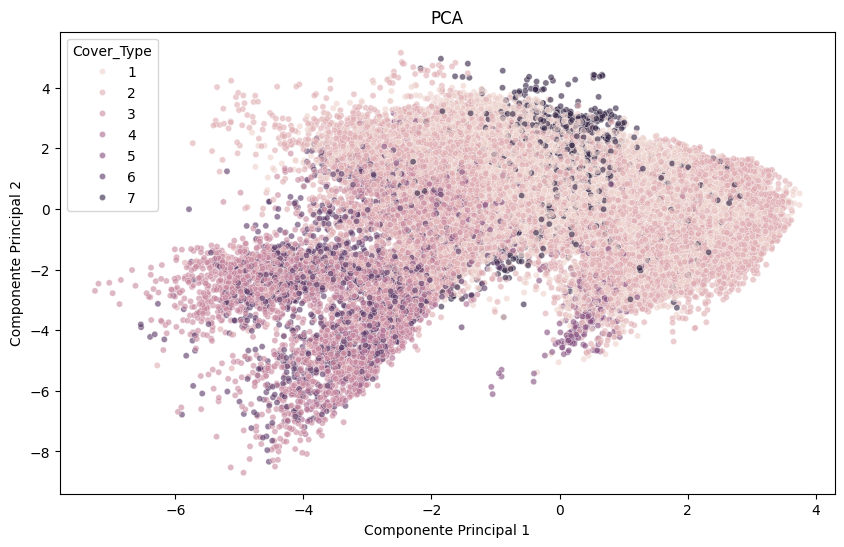

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca[TARGET_COLUMN] = y.values

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue=TARGET_COLUMN, alpha=0.6, s=20)
plt.title("PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title=TARGET_COLUMN)
plt.show()

Podemos verificar que as classes não ficam totalmente separadas, com bastante sobreposição entre os grupos, motsrando que apenas as duas primeiras componentes principais não são suficientes para separar claramente todas as classes.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [31]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)
print(kf)

(46480, 54)
(11621, 54)
(46480,)
(11621,)
KFold(n_splits=5, random_state=42, shuffle=True)


O Kfold divide os dados em várias partes, treinando e testando o modelo de formas diferentes, permitindo que as analises sejam mais bem executadas.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = scaler.transform(X_fold_val)

    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_fold_train_scaled, y_fold_train)
    pred = modelo.predict(X_fold_val_scaled)
    n_iter = modelo.n_iter_.max()
    convergiu = n_iter < modelo.max_iter
    print(fold, modelo.n_iter_, convergiu)

    resultados.append({
        "Acurácia": accuracy_score(y_fold_val, pred),
        "Precisão": precision_score(y_fold_val, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_fold_val, pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_fold_val, pred, average="weighted", zero_division=0)
    })
m = pd.DataFrame(resultados)
display(m)
display(m.mean().to_frame("Média"))

regressão logística multiclasse aprende padrões nos atributos para prever o tipo de cobertura que vai ira realizar. A validação em 5 folds avalia o modelo em diferentes divisões dos dados.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train)
X_test_final = scaler.transform(X_test)

modelo = LogisticRegression(C=0.01, max_iter=1000, random_state=42)

modelo.fit(X_train_final, y_train)

probabilidades = modelo.predict_proba(X_test_final)

print(modelo.classes_)

display(pd.DataFrame(
    probabilidades[:10],
    columns=[f"Classe {classe}" for classe in modelo.classes_]
))

[1 2 3 4 5 6 7]


,Classe 1,Classe 2,Classe 3,Classe 4,Classe 5,Classe 6,Classe 7
0,0.456718,0.523084,0.000064,0.000090,0.003085,0.000088,0.016871
1,0.038392,0.450021,0.152924,0.000451,0.013272,0.344410,0.000530
2,0.224398,0.734051,0.003887,0.000330,0.021610,0.011459,0.004264
3,0.237865,0.745048,0.000941,0.000087,0.011288,0.002022,0.002749
4,0.115367,0.728307,0.007653,0.000130,0.034959,0.113243,0.000341
5,0.598901,0.389038,0.000043,0.000037,0.001486,0.000146,0.010349
6,0.386811,0.597203,0.001345,0.000070,0.004976,0.003742,0.005852
7,0.240762,0.741702,0.000431,0.000106,0.014718,0.000629,0.001651
8,0.473949,0.519709,0.000124,0.000075,0.001559,0.000342,0.004242
9,0.000430,0.049232,0.717409,0.010652,0.002515,0.219762,0.000001


Cada coluna representa a probabilidade de a amostra pertencer a uma classe da variável alvo. Quando uma linha possui uma probabilidade muito maior que as outras, o modelo está mais confiante, então, quando os valores ficam próximos entre várias classes, a previsão é menos segura.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [56]:
modelo_sem = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

modelo_sem.fit(X_train_final, y_train)
probabilidades_sem = modelo_sem.predict_proba(X_test_final)
indices = range(10)
print(modelo_sem.classes_)

display(pd.DataFrame(
    probabilidades_sem[indices],
    columns=[f"Classe {classe}" for classe in modelo_sem.classes_]
))

[1 2 3 4 5 6 7]


,Classe 1,Classe 2,Classe 3,Classe 4,Classe 5,Classe 6,Classe 7
0,4.779047e-01,0.512566,1.215503e-08,1.450274e-08,1.659997e-03,4.642122e-09,7.868828e-03
1,3.109225e-02,0.429935,1.073498e-01,1.490047e-06,1.295030e-02,4.186708e-01,2.538197e-09
2,1.993353e-01,0.775794,9.012523e-04,4.874699e-07,2.257777e-02,1.317988e-03,7.351994e-05
3,2.155095e-01,0.771856,9.517771e-07,1.472775e-07,1.239896e-02,1.371806e-04,9.732805e-05
4,1.009095e-01,0.762008,3.635516e-03,1.013747e-06,3.051376e-02,1.029321e-01,1.488697e-07
5,6.328878e-01,0.358900,4.750063e-09,9.669349e-10,6.664802e-04,4.877268e-09,7.545315e-03
6,3.876715e-01,0.607608,1.360361e-04,2.124222e-07,3.825414e-03,4.457652e-04,3.132896e-04
7,2.229160e-01,0.762972,1.361985e-07,2.278046e-11,1.401508e-02,5.441223e-08,9.657432e-05
8,4.605671e-01,0.538920,9.640051e-07,4.283471e-08,2.903764e-06,1.457271e-07,5.090766e-04
9,8.670166e-09,0.008674,7.359574e-01,1.092123e-02,1.764148e-07,2.444470e-01,2.978682e-16


Sem regularização, o modelo fica menos limitado e pode gerar probabilidades mais extremas, indicando maior confiança em algumas previsões. Porém, isso também pode aumentar o risco de overfitting, pois o modelo pode se ajustar demais aos dados de treino.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [41]:
conf_reg = p.max(axis=1)
conf_sem_reg = probabilidades_sem.max(axis=1)

comparacao = pd.DataFrame({
    "Modelo": ["Com regularização", "Sem regularização"],
    "Confiança média": [conf_reg.mean(), conf_sem_reg.mean()]
})
display(comparacao)
display(pd.DataFrame({
    "Regularizado": conf_reg[:10],
    "Sem regularização": conf_sem_reg[:10],
    "Diferença": conf_sem_reg[:10] - conf_reg[:10]
}))

,Modelo,Confiança média
0,Com regularização,0.900525
1,Sem regularização,0.727571


,Regularizado,Sem regularização,Diferença
0,0.998819,0.512566,-0.486253
1,0.999954,0.429935,-0.570019
2,0.974259,0.775794,-0.198466
3,0.999518,0.771856,-0.227662
4,0.998645,0.762008,-0.236637
5,0.997155,0.632888,-0.364267
6,0.991459,0.607608,-0.383851
7,0.991455,0.762972,-0.228483
8,0.987025,0.538920,-0.448105
9,0.590190,0.735957,0.145767


O modelo sem regularização tende a apresentar probabilidades mais concentradas em uma única classe, resultando em maior confiança média. Porém, essa confiança maior nem sempre significa melhor desempenho, pois pode indicar maior risco de overfitting. Já o modelo com regularização L2 é mais controlado e tende a produzir previsões menos extremas.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [45]:
from sklearn.metrics import classification_report

pred_reg = modelo.predict(X_test_final)
pred_sem_reg = modelo_sem.predict(X_test_final)

print(classification_report(y_test, pred_reg, zero_division=0))
print(classification_report(y_test, pred_sem_reg, zero_division=0))

              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
           6       0.47      0.22      0.30       339
           7       0.70 

Comparando os relatórios, o melhor modelo é aquele que apresenta maiores valores de precision, recall e F1-score, principalmente nas classes com menor quantidade de amostras. Se o modelo sem regularização tiver métricas maiores, ele se ajustou melhor ao teste, porém, se a diferença for pequena, o modelo com regularização pode ser preferível por ser mais controlado e menos propenso a overfitting.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

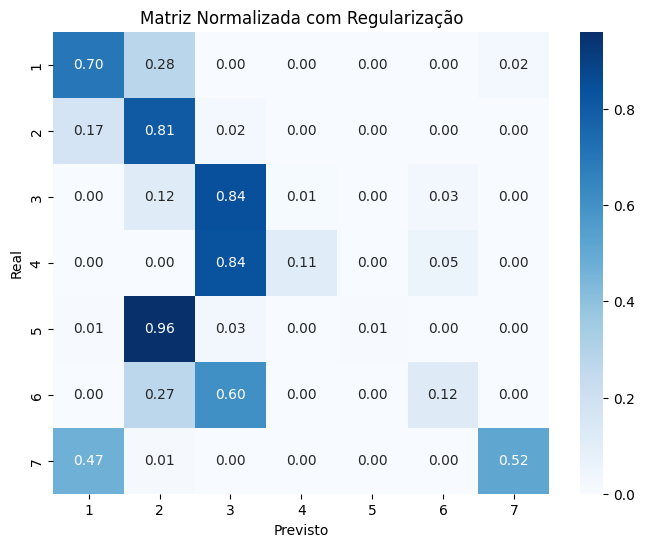

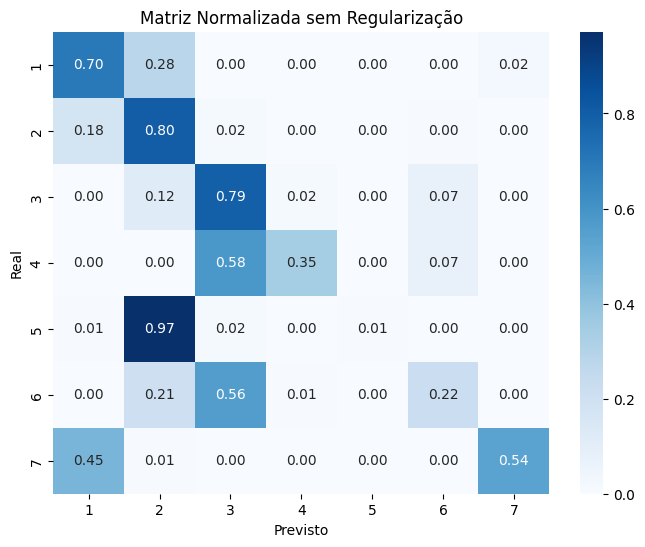

In [58]:
from sklearn.metrics import confusion_matrix

pred_reg = modelo.predict(X_test_final)
pred_sem_reg = modelo_sem.predict(X_test_final)

matriz_reg = confusion_matrix(y_test, pred_reg, normalize="true")
matriz_sem_reg = confusion_matrix(y_test, pred_sem_reg, normalize="true")

matriz_reg = pd.DataFrame(matriz_reg, index=modelo.classes_, columns=modelo.classes_)
matriz_sem_reg = pd.DataFrame(matriz_sem_reg, index=modelo_sem.classes_, columns=modelo_sem.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_reg, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz Normalizada com Regularização")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_sem_reg, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz Normalizada sem Regularização")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

As classes melhor classificadas são aquelas com maiores valores na diagonal principal. Valores altos fora da diagonal indicam confusão entre classes. Comparando as duas matrizes, é possível verificar se a regularização reduziu ou aumentou os erros entre classes específicas.